In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.8 MB/s eta 0:00:00


**PENDAHULUAN**

**1.Latar Belakang Masalah**

<p align = "justify">Dalam proses pengambilan keputusan, terutama yang berkaitan dengan pembelian mobil bekas, sering kali diperlukan pertimbangan terhadap berbagai aspek seperti harga beli, biaya perawatan, kondisi kendaraan, dan tingkat keamanan. Namun, informasi-informasi ini sering kali bersifat subjektif dan tidak memiliki batasan yang tegas. Misalnya, apakah harga mobil dianggap “mahal” atau “murah” dapat berbeda tergantung persepsi masing-masing individu.

<p align = "justify">Untuk mengatasi ketidakpastian tersebut, salah satu pendekatan yang dapat digunakan adalah sistem logika fuzzy. Sistem ini memungkinkan penggunaan nilai linguistik (seperti “murah”, “sedang”, “mahal”) dan mampu menangani data yang tidak pasti atau ambigu. Dengan menerapkan logika fuzzy, proses penilaian kelayakan mobil bekas dapat dilakukan secara lebih fleksibel dan mendekati cara manusia dalam mengambil keputusan.

<p align = "justify">Dataset yang digunakan dalam penelitian ini adalah Car Evaluation Dataset dari Kaggle, yang menyajikan data hasil evaluasi mobil berdasarkan atribut seperti harga beli, biaya perawatan, jumlah pintu, kapasitas penumpang, ukuran bagasi, dan tingkat keamanan. Atribut-atribut ini kemudian akan diproses menggunakan dua pendekatan sistem fuzzy untuk menentukan tingkat kelayakan kendaraan.

</div>


**2.Metode**

**i. Paparan, Statistik, dan Sumber Dataset**

<div style="text-align: justify; padding: 10px;">

<p align = "justify">Dataset yang digunakan dalam penelitian ini adalah Car Evaluation Dataset yang diunduh dari platform [Kaggle (https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set)]. Dataset ini merupakan hasil transformasi dari multi-valued attributes ke bentuk numerik berdasarkan keputusan logis dan kriteria evaluasi kendaraan.

<p align = "justify">Dataset ini memiliki total 1.728 baris data dengan 6 atribut input dan 1 atribut output (kelas evaluasi kendaraan). Atribut-atribut tersebut adalah sebagai berikut:

</div>


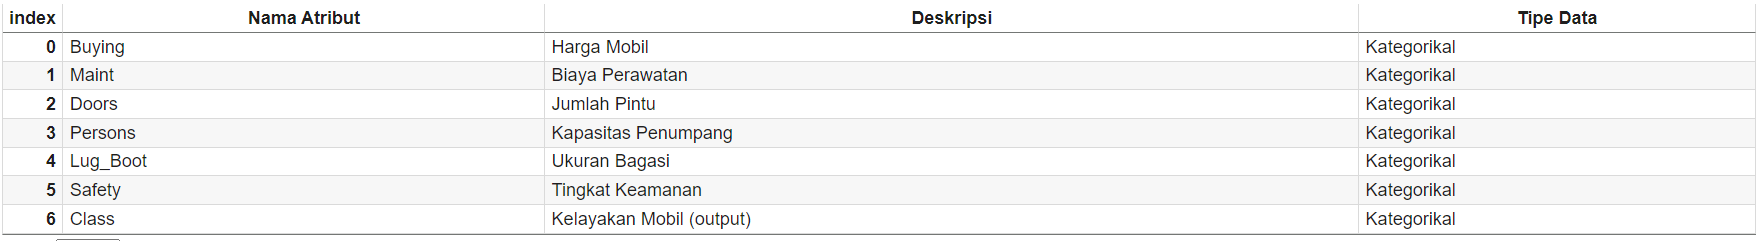

**Statistik Data**

In [ ]:
import pandas as pd

# Membaca file CSV dari direktori /content/
df = pd.read_csv('/content/car_evaluation.csv')

# Tampilkan 5 data awal
print(df.head())

   vhigh vhigh.1  2 2.1  small   low  unacc
0  vhigh   vhigh  2   2  small   med  unacc
1  vhigh   vhigh  2   2  small  high  unacc
2  vhigh   vhigh  2   2    med   low  unacc
3  vhigh   vhigh  2   2    med   med  unacc
4  vhigh   vhigh  2   2    med  high  unacc


ii.	Paparan pre-processing dataset

In [ ]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

pd.set_option('future.no_silent_downcasting', True)

# Contoh: Membaca data (misalnya dari file CSV atau buat DataFrame manual)
# Gantilah baris ini dengan pembacaan data Anda yang sebenarnya
df = pd.DataFrame({
    'buying': ['low', 'med', 'high'],
    'maint': ['med', 'high', 'low'],
    'doors': ['2', '3', '5more'],
    'persons': ['2', '4', 'more'],
    'lug_boot': ['small', 'big', 'big'],
    'safety': ['low', 'high', 'med'],
    'class': ['unacc', 'acc', 'vgood']
})

# Pemetaan label ke angka
label_mapping = {
    'low': 1,
    'med': 2,
    'high': 3,
    'vhigh': 4,
    'small': 1,
    'big': 3,
    'more': 5,
    'more': 5,
    'unacc': 0,
    'acc': 1,
    'good': 2,
    'vgood': 3
}

# Gantilah nilai berdasarkan mapping
df.replace(label_mapping, inplace=True)

# Ubah semua kolom ke numerik
df = df.apply(pd.to_numeric)

print(df)

   buying  maint  doors  persons  lug_boot  safety  class
0       1      2      2        2         1       1      0
1       2      3      3        4         3       3      1
2       3      1      5        5         3       2      3


Acceptability Score (Mamdani): 2.439814814814815


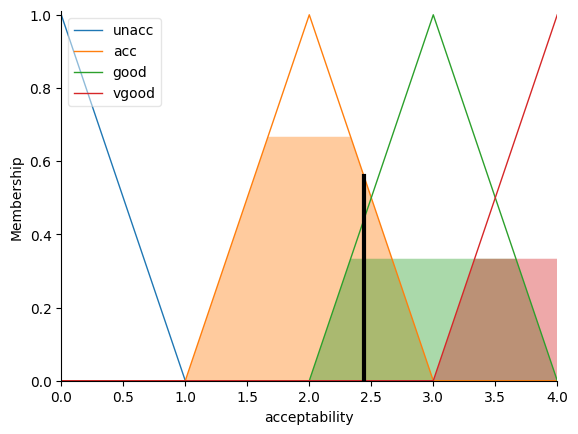

In [ ]:
# Buat variabel input
price = ctrl.Antecedent(np.arange(1, 5, 1), 'price')
safety = ctrl.Antecedent(np.arange(1, 5, 1), 'safety')

# Buat variabel output
acceptability = ctrl.Consequent(np.arange(0, 5, 1), 'acceptability')

# Buat fungsi keanggotaan untuk input secara otomatis (3 kategori: poor, average, good)
price.automf(3)
safety.automf(3)

# Buat fungsi keanggotaan output secara manual (4 kategori)
acceptability['unacc'] = fuzz.trimf(acceptability.universe, [0, 0, 1])
acceptability['acc']   = fuzz.trimf(acceptability.universe, [1, 2, 3])
acceptability['good']  = fuzz.trimf(acceptability.universe, [2, 3, 4])
acceptability['vgood'] = fuzz.trimf(acceptability.universe, [3, 4, 4])

# Buat aturan fuzzy
rule1 = ctrl.Rule(price['poor'] & safety['poor'], acceptability['unacc'])
rule2 = ctrl.Rule(price['average'] & safety['average'], acceptability['acc'])
rule3 = ctrl.Rule(price['good'] & safety['good'], acceptability['good'])
rule4 = ctrl.Rule(price['good'] & safety['average'], acceptability['vgood'])  # Tambahan contoh

# Buat sistem fuzzy dan simulasi
accept_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
accept_sim = ctrl.ControlSystemSimulation(accept_ctrl)

# Input nilai (pastikan dalam rentang)
accept_sim.input['price'] = 3
accept_sim.input['safety'] = 3
accept_sim.compute()

# Hasil output
print("Acceptability Score (Mamdani):", accept_sim.output['acceptability'])

# Optional: Visualisasi
acceptability.view(sim=accept_sim)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('/content/car_evaluation.csv')
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# Konversi ordinal ke angka
ordinal_map = {
    'buying': {'vhigh': 4, 'high': 3, 'med': 2, 'low': 1},
    'maint': {'vhigh': 4, 'high': 3, 'med': 2, 'low': 1},
    'doors': {'2': 2, '3': 3, '4': 4, '5more': 5},
    'persons': {'2': 2, '4': 4, 'more': 5},
    'lug_boot': {'small': 1, 'med': 2, 'big': 3},
    'safety': {'low': 1, 'med': 2, 'high': 3},
    'class': {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
}
for col in ordinal_map:
    df[col] = df[col].map(ordinal_map[col])

# Fitur utama Sugeno
X = df[['buying', 'safety', 'lug_boot']]
y = df['class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression sebagai output Sugeno
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred = np.round(model.predict(X_test)).astype(int)
y_pred = np.clip(y_pred, 0, 3)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Akurasi Sugeno:", accuracy)
print("F1-Score Sugeno:", f1)

Akurasi Sugeno: 0.6705202312138728
F1-Score Sugeno: 0.6654336483332522


**iii.	Penjelasan mengenai rancangan dua metode yang digunakan: jumlah nilai lingustik untuk setiap atribut, fungsi keanggotaan, batas-batas nilai linguistik, Fuzzy rule**